## Basic Regression

In [1]:
"""
1.	Basic Regression
a.	Import the data from tab ‘Sales Data’.
b.	Run a linear regression model to explain order size in terms of Ad_Budget and Distance.  
c.	Assess the results. Are there problems? 
d.	Determine if Distance belongs in the model.
e.	Rerun the model without distance.
"""

import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Sales Data", index_col="Observation")
df.head(3)

,Order_Size,Ad_Budget,Male,Distance
Observation,,,,
1,20.77,3975,0,20
2,49.52,10897,0,5
3,66.40,15067,0,4


In [3]:
print(df.dtypes)
print(df.info())
print(df.describe())
print(df.shape)
print(df["Male"].unique())

Order_Size    float64
Ad_Budget       int64
Male            int64
Distance        int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_Size  200 non-null    float64
 1   Ad_Budget   200 non-null    int64  
 2   Male        200 non-null    int64  
 3   Distance    200 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 7.8 KB
None
       Order_Size     Ad_Budget        Male    Distance
count  200.000000    200.000000  200.000000  200.000000
mean    56.575000  10489.520000    0.280000    8.320000
std     22.310774   6616.043323    0.450126    4.555366
min      8.550000  -2883.000000    0.000000    1.000000
25%     38.712500   5312.750000    0.000000    5.000000
50%     58.325000   9589.000000    0.000000    7.000000
75%     71.532500  14443.500000    1.000000   10.000000
max    135.300000  36039.000000    1.000000   25.0

In [4]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Order_Size ~ Ad_Budget + Distance', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Order_Size   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     178.6
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           5.64e-45
Time:                        15:19:29   Log-Likelihood:                -800.86
No. Observations:                 200   AIC:                             1608.
Df Residuals:                     197   BIC:                             1618.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     26.8988      2.583     10.415      0.0

Above model returns a p-value for F-statistic of 5.64e-45, less than the defined alpha level of 0.05, indicating a significant predictive power of the model. The adjusted R-squared is 0.641, meaning that 64.1% of the variance of Order Size is explained by Ad Budget and Distance. When we look at the p-values of the individual t-tests, we see that it is 0.0001 for Ad Budget, and 0.49 for Distance. Because 0.49 is greater than our alpha level of 0.05, we do not reject the null hypothesis that the coefficient of Distant is equal to 0. This tells us that Distance is not a statistically significant predictor in this model. We cannot confidently say that Distant affects Order Size.

Upon assessment, this model is heterosketastic.

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'sklearn.linear_model._base.LinearRegression'>
LinearRegression()


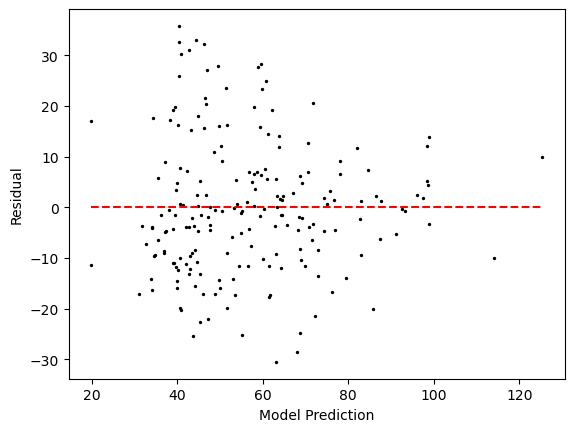


This looks like heterostaticity. Higher variance in residual with lower predicted values.
Mean of Residuals: 9.947598300641404e-16


In [5]:
#Import the required package from sklearn
from sklearn.linear_model import LinearRegression

'''
In order to input data from a pandas dataframe and into a sci-kit function,
we need to convert the dataframe series into NumPy Arrays. This can be done
with the values function.
'''
train_X = df[['Ad_Budget','Distance']].values
# print(train_X)
print(type(train_X))

train_y = df['Order_Size'].values
# print(train_y)
print(type(train_y))

'''
Fitting data to a regression model requires two arguments, the training X
values (independent variables) and the training y values (dependent variables.
In general, most fit functions for models follow this format.
'''
reg = LinearRegression().fit(train_X, train_y)
# print(reg)
print(type(reg))
print(reg)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

print(f"\nThis looks like heterostaticity. Higher variance in residual with lower predicted values.")

# We can also look at how close the mean of the residuals is to zero.

print('Mean of Residuals:',residuals.mean())

In [6]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Order_Size ~ Ad_Budget', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Order_Size   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     357.7
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           3.01e-46
Time:                        15:32:05   Log-Likelihood:                -801.10
No. Observations:                 200   AIC:                             1606.
Df Residuals:                     198   BIC:                             1613.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     28.1951      1.773     15.904      0.0

Re-ran the model. The R-squared improved slightly.

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'sklearn.linear_model._base.LinearRegression'>
LinearRegression()


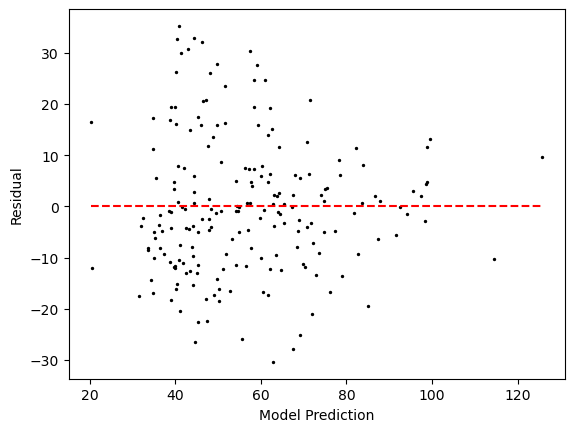


This looks like heterostaticity. Higher variance in residual with lower predicted values.
Mean of Residuals: -1.6342482922482305e-15


In [7]:
'''
In order to input data from a pandas dataframe and into a sci-kit function,
we need to convert the dataframe series into NumPy Arrays. This can be done
with the values function.
'''
train_X = df[['Ad_Budget']].values
# print(train_X)
print(type(train_X))

train_y = df['Order_Size'].values
# print(train_y)
print(type(train_y))

'''
Fitting data to a regression model requires two arguments, the training X
values (independent variables) and the training y values (dependent variables.
In general, most fit functions for models follow this format.
'''
reg = LinearRegression().fit(train_X, train_y)
# print(reg)
print(type(reg))
print(reg)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

print(f"\nThis looks like heterostaticity. Higher variance in residual with lower predicted values.")

# We can also look at how close the mean of the residuals is to zero.

print('Mean of Residuals:',residuals.mean())

## Bimodal Error 1

In [9]:
"""
2.	Bimodal Error 1
a.	Import the data from tab ‘Bimodal Error 1’.
b.	Run the linear regression model y = b0 + b1 x1 + b2 x2 with the default settings.
c.	Examine the regression output table.  Does it look OK?  
d.	Now look at the distribution of the error term.  What problems do you see here?
"""

import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Bimodal Error 1", index_col="Obs")
df.head(3)

,Y,X1,X2
Obs,,,
1,2258,10,25
2,7542,62,27
3,4254,29,33


In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Y ~ X1 + X2', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.188e+04
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          4.30e-206
Time:                        16:05:47   Log-Likelihood:                -1394.6
No. Observations:                 200   AIC:                             2795.
Df Residuals:                     197   BIC:                             2805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1159.3613     82.674     14.023      0.0

In [12]:
#Import the required package from sklearn
from sklearn.linear_model import LinearRegression

'''
In order to input data from a pandas dataframe and into a sci-kit function,
we need to convert the dataframe series into NumPy Arrays. This can be done
with the values function.
'''
train_X = df[['X1','X2']].values
# print(train_X)
print(type(train_X))

train_y = df['Y'].values
# print(train_y)
print(type(train_y))

'''
Fitting data to a regression model requires two arguments, the training X
values (independent variables) and the training y values (dependent variables.
In general, most fit functions for models follow this format.
'''
reg = LinearRegression().fit(train_X, train_y)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


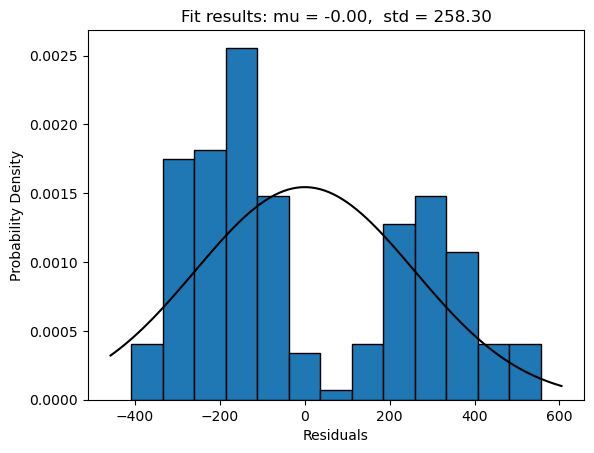

In [13]:
from scipy.stats import norm
import numpy as np

# Fit a normal distribution to the data:
mean, std = norm.fit(residuals)

# Plot the histogram.
plt.hist(residuals, bins=13, edgecolor='black', density=True)

# Generate a PDF based on the fitted distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std)
plt.plot(x, p, color='black')
title = "Fit results: mu = %.2f,  std = %.2f" % (mean, std)
plt.xlabel("Residuals")
plt.ylabel("Probability Density")
plt.title(title)

plt.show()

We can see a bimodal distribution of the residuals. Probability density of the residuals peak at around -200 and 300. The model is rarely making small prediction errors, but is consistently making large negative or positive errors. In a healthy model, the distribution should be normally distributed, meaning it should not make, or make very small errors most of the time, and make very few large errors.

Because the F-test and T-tests assume that the distribution of the residuals follows a bell curve, we can no longer trust the validity of these tests.

When residuals split into two separate peaks like this, it is a massive red flag that your model is fundamentally missing a piece of the puzzle.

It usually means there are two distinct sub-populations hidden within your data, and your model is trying to draw a single line right down the middle of them. Because the line splits the difference, it consistently over-predicts one group (causing the negative peak) and under-predicts the other group (causing the positive peak).

## Bimodal Error 2

In [2]:
"""
3.	Bimodal Error 2
a.	Import the data from tab ‘Bimodal Error 2’. This data is the same as the Bimodal Error 1 data, however we have added a ‘dummy’ variable (more on this next class). 
b.	Run the linear regression model y = b0 + b1 x1 + b2 x2 + b3 US.
c.	Examine the regression output table and error distribution.  Suppose this reflected store sales data for stores in Canada and the US where x1 and x2 were measures of local customer base and economic activity.  
Explain to your manager why the results were different.
"""

import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Bimodal Error 2", index_col="Obs")
df.head(3)

,Y,X1,X2,US
Obs,,,,
1,2258,10,25,0
2,7542,62,27,0
3,4254,29,33,0


In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Y ~ X1 + X2 + US', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.483e+04
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          2.89e-286
Time:                        16:20:23   Log-Likelihood:                -1201.3
No. Observations:                 200   AIC:                             2411.
Df Residuals:                     196   BIC:                             2424.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1014.1135     31.820     31.870      0.0

In [16]:
#Import the required package from sklearn
from sklearn.linear_model import LinearRegression

'''
In order to input data from a pandas dataframe and into a sci-kit function,
we need to convert the dataframe series into NumPy Arrays. This can be done
with the values function.
'''
train_X = df[['X1','X2', 'US']].values
# print(train_X)
print(type(train_X))

train_y = df['Y'].values
# print(train_y)
print(type(train_y))

'''
Fitting data to a regression model requires two arguments, the training X
values (independent variables) and the training y values (dependent variables.
In general, most fit functions for models follow this format.
'''
reg = LinearRegression().fit(train_X, train_y)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


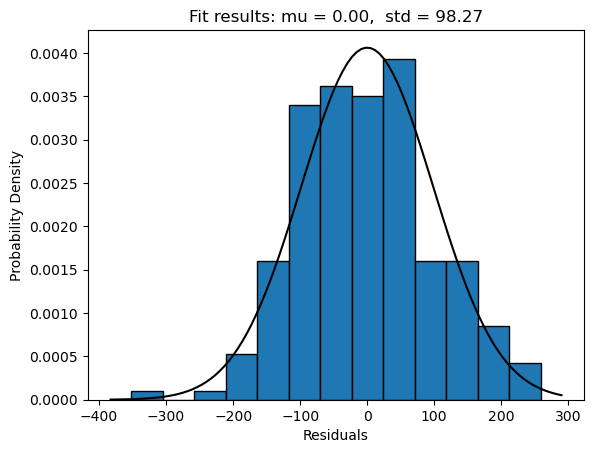

In [17]:
from scipy.stats import norm
import numpy as np

# Fit a normal distribution to the data:
mean, std = norm.fit(residuals)

# Plot the histogram.
plt.hist(residuals, bins=13, edgecolor='black', density=True)

# Generate a PDF based on the fitted distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std)
plt.plot(x, p, color='black')
title = "Fit results: mu = %.2f,  std = %.2f" % (mean, std)
plt.xlabel("Residuals")
plt.ylabel("Probability Density")
plt.title(title)

plt.show()

1. We Stopped Forcing a "One-Size-Fits-All" ModelIn the previous iteration, the model tried to draw a single trendline for all stores based only on customer base ($x_1$) and economic activity ($x_2$). However, Canadian and US stores operate in fundamentally different environments (e.g., currency differences, distinct consumer behaviors, or different pricing structures). Because the model lacked a way to distinguish between the two countries, it systematically over-predicted sales for one country and under-predicted sales for the other. This created the bimodal "two-peak" error distribution we saw previously.2. The New Variable Created Distinct BaselinesBy introducing the US = [0,1] categorical variable (a dummy variable), we effectively gave the model permission to establish two separate baselines (intercepts): one for Canada (US = 0) and one for the United States (US = 1). The model no longer has to split the difference between the two markets.

Restored Normality: The residuals now follow a healthy, unimodal normal distribution (the single bell curve centered at zero). This proves that by controlling for the country, we eliminated the systematic bias. The errors left over are now truly random noise, which satisfies the core assumption of linear regression.

Massively Improved Accuracy: In your previous bimodal plot, the standard deviation (std) of the errors was 258.30. By simply adding this country flag, the standard deviation dropped to 98.27. The model's predictions are now significantly tighter and much closer to reality.

Trustworthy Statistical Tests: Because the residual distribution is now normal, we can confidently rely on our F-tests and T-tests to make business decisions moving forward.

## Non-Normal Errors

In [18]:
"""
4.	Non-Normal Errors
a.	Import the data from the tab ‘Nonlinear’.
b.	Run the linear regression y = b0 + b1x1.
c.	Examine the residual plot. Notice the pattern. 
d.	Re-run the regression including the X1Squared variable. Note the difference in the residual plot.
"""

import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Nonlinear", index_col="Obs")
df.head(3)

,Y,X1,X1Squared
Obs,,,
1,448.862636,6,36
2,560.644994,1,1
3,538.691453,1,1


In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Y ~ X1 + X1Squared', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     422.1
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           2.20e-71
Time:                        16:32:29   Log-Likelihood:                -1072.5
No. Observations:                 197   AIC:                             2151.
Df Residuals:                     194   BIC:                             2161.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    419.2591     16.245     25.808      0.0

In [22]:
#Import the required package from sklearn
from sklearn.linear_model import LinearRegression

'''
In order to input data from a pandas dataframe and into a sci-kit function,
we need to convert the dataframe series into NumPy Arrays. This can be done
with the values function.
'''
train_X = df[['X1']].values
# print(train_X)
print(type(train_X))

train_y = df['Y'].values
# print(train_y)
print(type(train_y))

'''
Fitting data to a regression model requires two arguments, the training X
values (independent variables) and the training y values (dependent variables.
In general, most fit functions for models follow this format.
'''
reg = LinearRegression().fit(train_X, train_y)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


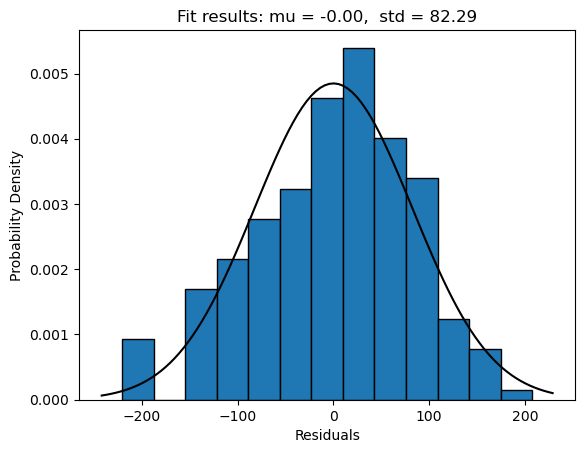

In [23]:
from scipy.stats import norm
import numpy as np

# Fit a normal distribution to the data:
mean, std = norm.fit(residuals)

# Plot the histogram.
plt.hist(residuals, bins=13, edgecolor='black', density=True)

# Generate a PDF based on the fitted distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std)
plt.plot(x, p, color='black')
title = "Fit results: mu = %.2f,  std = %.2f" % (mean, std)
plt.xlabel("Residuals")
plt.ylabel("Probability Density")
plt.title(title)

plt.show()

In [24]:
#Import the required package from sklearn
from sklearn.linear_model import LinearRegression

'''
In order to input data from a pandas dataframe and into a sci-kit function,
we need to convert the dataframe series into NumPy Arrays. This can be done
with the values function.
'''
train_X = df[['X1', 'X1Squared']].values
# print(train_X)
print(type(train_X))

train_y = df['Y'].values
# print(train_y)
print(type(train_y))

'''
Fitting data to a regression model requires two arguments, the training X
values (independent variables) and the training y values (dependent variables.
In general, most fit functions for models follow this format.
'''
reg = LinearRegression().fit(train_X, train_y)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


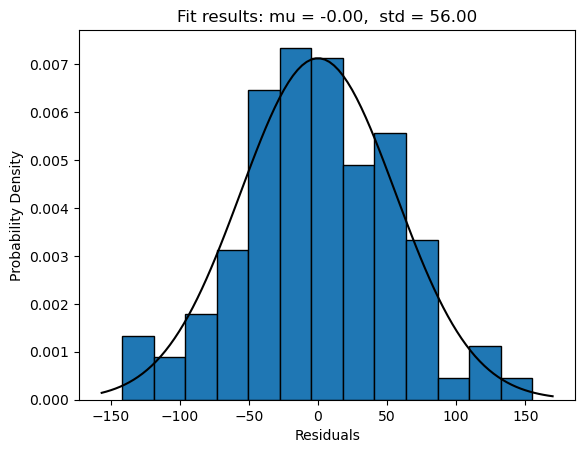

In [25]:
from scipy.stats import norm
import numpy as np

# Fit a normal distribution to the data:
mean, std = norm.fit(residuals)

# Plot the histogram.
plt.hist(residuals, bins=13, edgecolor='black', density=True)

# Generate a PDF based on the fitted distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std)
plt.plot(x, p, color='black')
title = "Fit results: mu = %.2f,  std = %.2f" % (mean, std)
plt.xlabel("Residuals")
plt.ylabel("Probability Density")
plt.title(title)

plt.show()

The Histogram is more spread apart with larger std when we only include variable X as the independent variable. When we add the X_squared variable, the histogram is less spread apart. There is smaller probability of having larger residuals. This indicates that the relationship between the dependent and the independent variables are not linear.

## Outliers

In [4]:
"""
a.	Import the data from the tab ‘Outliers’.
b.	Run the linear regression y = b0 + b1x1 + Outlier.
c.	Examine the Cook’s D plot and observe the single outlier. 
"""
import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Outliers", index_col="Obs")
df.head(3)

,Y,X,Outlier
Obs,,,
1,70,3,2
2,103,7,4
3,143,7,4


In [5]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Y ~ X + Outlier', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     58.67
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           1.77e-17
Time:                        18:20:31   Log-Likelihood:                -432.04
No. Observations:                 101   AIC:                             870.1
Df Residuals:                      98   BIC:                             877.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     86.4067      4.088     21.139      0.0

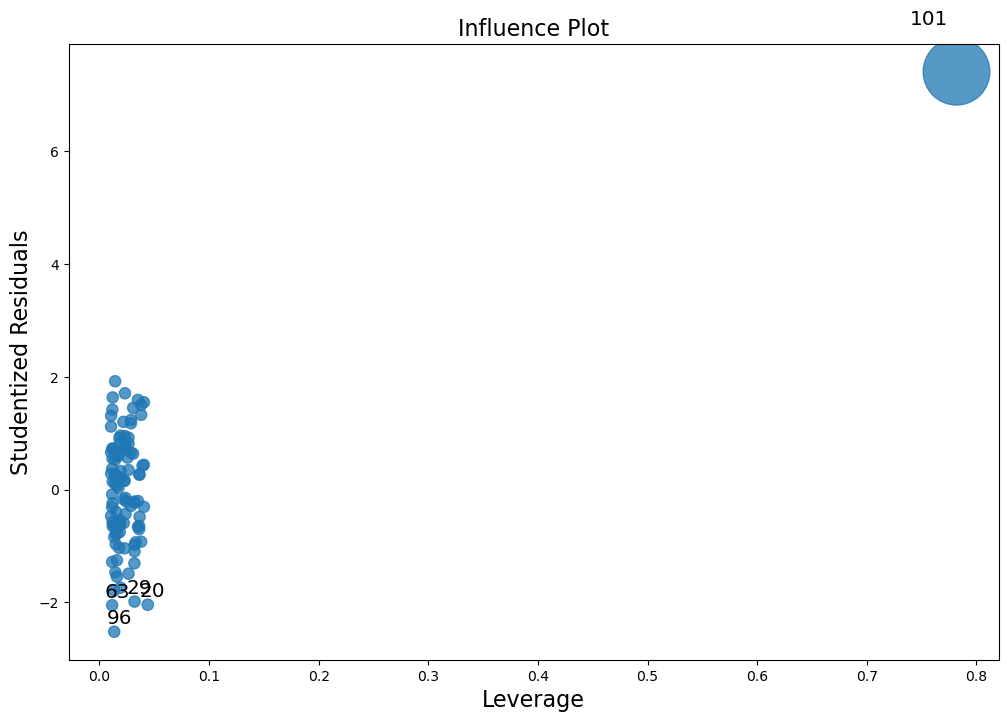

In [7]:
#Import the required package from sklearn
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

train_X = df[['X','Outlier']].values
train_y = df['Y'].values

reg = LinearRegression().fit(train_X, train_y)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

#In a similar fashion to how the QQ plot was built, this plot can be generated.
fig, ax = plt.subplots(figsize=(12,8))
fig = sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
plt.show()

There is a single, massive bubble in the top-right corner labeled 101. This point is significantly separated from the rest of the data on both axes and has a much larger bubble size. This visually confirms step "c" from your instructions, indicating that data point 101 is a severe outlier with a highly disproportionate influence on the regression model.

## Heteroskedasticity 

In [10]:
"""
6.	Heteroskedasticity 
a.	Import the data from tab ‘Heteroskedasticity’. 
b.	Run a linear regression model on the data using y = b0 + b1 x1 + b2 x2. Assess for heteroskedasticity.
"""

import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Heteroskedasticity", index_col="Obs")
df.head(3)

,Y,X1,X2
Obs,,,
1,4084,38,22
2,4828,45,24
3,10304,98,21


In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Y ~ X1 + X2', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.532e+04
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          8.06e-145
Time:                        18:31:03   Log-Likelihood:                -593.82
No. Observations:                 100   AIC:                             1194.
Df Residuals:                      97   BIC:                             1201.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     93.1518     62.684      1.486      0.1

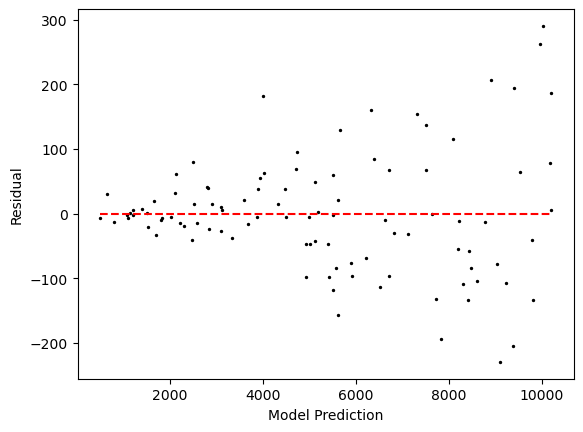


This looks like heterostaticity. Higher variance in residual with lower predicted values.
Mean of Residuals: -4.877165338257328e-13


In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

train_X = df[['X1','X2']].values
train_y = df['Y'].values

reg = LinearRegression().fit(train_X, train_y)

#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

print(f"\nThis looks like heterostaticity. Higher variance in residual with higher predicted values.")

# We can also look at how close the mean of the residuals is to zero.

print('Mean of Residuals:',residuals.mean())

## Collinearity

In [16]:
"""
a.	Import the data from the tab ‘Collinear’. 
b.	Run a linear regression to explain y in terms of experience and height.  Does height appear to explain y?
c.	Run a linear regression to explain y in terms of experience and weight.  Does weight appear explain y?
d.	Run a linear regression to explain y in terms of experience and height and weight. Explain the results in language a manager would understand.
"""

import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Collinear", index_col="Obs")
df.head(3)

,Y,Experience,Height,Weight
Obs,,,,
1,450,3,52,58
2,330,3,33,36
3,505,5,37,52


In [20]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Y ~ Experience + Height', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     255.0
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           2.36e-39
Time:                        18:46:32   Log-Likelihood:                -540.07
No. Observations:                 100   AIC:                             1086.
Df Residuals:                      97   BIC:                             1094.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9241     16.868      0.055      0.9

In [21]:
model = ols('Y ~ Experience + Weight', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     217.0
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           1.55e-36
Time:                        18:46:32   Log-Likelihood:                -546.75
No. Observations:                 100   AIC:                             1100.
Df Residuals:                      97   BIC:                             1107.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.4614     20.496     -0.510      0.6

In [22]:
model = ols('Y ~ Experience + Height + Weight', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     168.3
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           4.27e-38
Time:                        18:46:32   Log-Likelihood:                -540.07
No. Observations:                 100   AIC:                             1088.
Df Residuals:                      96   BIC:                             1099.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5994     19.543      0.082      0.9

Collinearity (often used interchangeably with multicollinearity) is a statistical phenomenon in multiple regression analysis where two or more independent variables (the predictors) are highly correlated with one another.

In simpler terms, it means that two or more variables are essentially providing the same information to your model.

Why This Happens (Explaining Collinearity)
"This happens because Height and Weight are highly redundant—they essentially tell us the exact same underlying story about the data. Because taller people generally weigh more, the model gets confused when we include both at the same time. The data shows that Height is the stronger metric of the two. Once the model knows a person's Height, knowing their Weight gives us zero additional predictive power."

The Recommendation
"We should drop Weight from our analysis entirely. Tracking it adds unnecessary clutter to our data pipelines. Our final, most efficient model should only use Experience and Height to predict Y."

## Diminishing Returns

In [23]:
"""
8.	Diminishing Returns
a.	Import the data from the tab ‘Diminishing Returns’
b.	Run a linear regression to explain sales in terms of price and ad_budget. Observe the plots – does anything look strange?
c.	Create a new variable called ln_ad_budget which is the natural log of ad_budget (in Python, the command is ‘log’ in the math package)
d.	Run a linear regression to explain sales in terms of price and ln_ad_budget. Observe the plots – what has changed?
"""

import os
import pandas as pd

path = os.path.join(os.path.curdir, "MMA 860 Assessing and Testing Data File v1.0.xlsx")
df = pd.read_excel(path, sheet_name="Diminishing Returns", index_col="Obs")
df.head(3)

,Sales,Price,Ad_Budget
Obs,,,
1,15590.994286,33,7266.240314
2,16257.210376,29,9482.567351
3,15343.437706,36,7657.476014


In [24]:
model = ols('Sales ~ Price + Ad_Budget', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.437e+04
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          2.32e-128
Time:                        18:56:05   Log-Likelihood:                -523.05
No. Observations:                  97   AIC:                             1052.
Df Residuals:                      94   BIC:                             1060.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.773e+04     25.622    692.010      0.0

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'sklearn.linear_model._base.LinearRegression'>
LinearRegression()


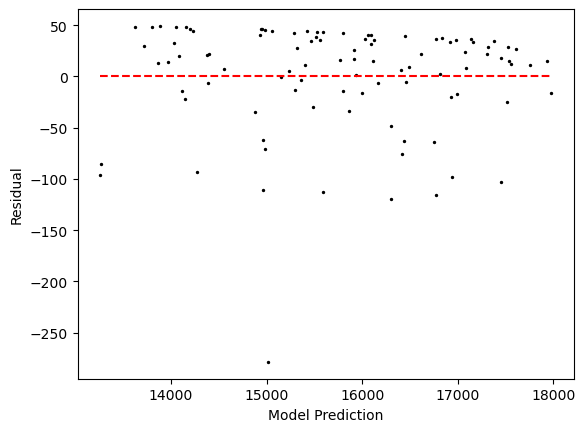

Mean of Residuals: 4.688117019448083e-13


In [26]:
#Import the required package from sklearn
from sklearn.linear_model import LinearRegression

'''
In order to input data from a pandas dataframe and into a sci-kit function,
we need to convert the dataframe series into NumPy Arrays. This can be done
with the values function.
'''
train_X = df[['Price','Ad_Budget']].values
# print(train_X)
print(type(train_X))

train_y = df['Sales'].values
# print(train_y)
print(type(train_y))

'''
Fitting data to a regression model requires two arguments, the training X
values (independent variables) and the training y values (dependent variables.
In general, most fit functions for models follow this format.
'''
reg = LinearRegression().fit(train_X, train_y)
# print(reg)
print(type(reg))
print(reg)


#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y

import matplotlib.pyplot as plt
plt.scatter(predicted_y,residuals,s=2,c='black')

#This line adds the dashed horizontal line
plt.hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')

plt.xlabel("Model Prediction")
plt.ylabel("Residual")
plt.show()

# We can also look at how close the mean of the residuals is to zero.

print('Mean of Residuals:',residuals.mean())

The "Ceiling" Effect: Notice how the residuals seem to hit a hard, flat ceiling around the +50 mark. They do not scatter randomly upward.

Increasing Variance (Heteroscedasticity): As the model's predictions increase (moving from left to right on the x-axis), the spread of the errors gets much wider. It creates a sort of downward-opening fan or funnel shape.

Heavy Negative Skew at High Predictions: As the model predicts higher sales (above 15,000), it generates massive negative residuals, dropping down to almost -300.

Why Diminishing Returns Causes This
This specific pattern—particularly the huge negative residuals at higher predicted values—is exactly what a linear model looks like when it is forced onto data that has diminishing returns.

Here is the underlying mechanic:

The Linear Assumption: The linear model assumes that for every extra dollar spent on Ad_Budget, Sales will increase by a constant amount, forever. It draws a straight line pointing upward.

The Reality of Diminishing Returns: In reality, the effectiveness of the ad spend tapers off. The actual sales curve flattens out.

The Resulting Error: Because the linear model keeps predicting higher and higher sales, but the actual sales have flattened, the model ends up drastically over-predicting the outcome.

The Math: Residuals are calculated as Actual Sales - Predicted Sales. If the actual sales are flattening but the predicted sales are soaring, that equation produces large negative numbers.